# Linearity Tests and Jacobian Comparison

**Note:** This notebook implements the linearity tests described the paper.
The theoretical background below is reproduced from the paper for reference.

Both Traditional-NPZ and PI-NPZ encode the sensitivities of state variables to perturbations in Jacobian matrices that guide initial state adjustments during state estimation.
Accurate Jacobians are essential for 4D-Var because they determine the gradient directions used to adjust initial states toward observations, as errors in the Jacobians would lead optimization away from the true state or cause convergence failures.
We begin by formalizing the role of Jacobians through the tangent-linear model.
We obtain the tangent-linear model by linearizing the forecast operator $M$ around $\mathbf{x}_i$:
\begin{equation}
\delta \mathbf{x}_{i+1} = \mathbf{M}_{i+1,i}\, \delta \mathbf{x}_i,
\end{equation}
where $\mathbf{M}_{i+1,i}$ is the Jacobian of the forecast operator evaluated at $\mathbf{x}_i$.
The tangent-linear model, built from Jacobians evaluated along the trajectory, captures how infinitesimal perturbations amplify, decay, or rotate as the system evolves, providing a core diagnostic of dynamical stability and sensitivity.

For Traditional-NPZ, the tangent-linear model is obtained by linearizing the NPZ equations around the reference trajectory $\mathbf{x}_i$, with the resulting linearized system integrated forward in time using the same RK4 scheme as the nonlinear model.
The adjoint operator propagates sensitivities backward in time and is necessary to compute gradients efficiently in 4D-Var.
In practice, this requires deriving and maintaining both tangent-linear and adjoint codes alongside the forward model, a process that can take weeks for complex biogeochemical systems.
While tools can generate these operators automatically, they are often derived manually due to model complexity or discontinuities, and must be updated whenever the forward model changes.
By contrast, PI-NPZ leverages AD: the same gradients used for backpropagation during training automatically provide Jacobians with respect to the input state, eliminating the need for separate tangent-linear and adjoint codes.

The practical value of these AD-derived Jacobians hinges on their accuracy as local linearizations of PI-NPZ's nonlinear dynamics.
We evaluated this by testing whether the tangent-linear operator $\mathbf{M}$ provides a faithful first-order Taylor expansion of the nonlinear forecast operator $M$:
\begin{equation}
\lim_{\alpha \to 0} \Big[ M(\mathbf{x}_0 + \alpha \delta \mathbf{x}) 
 - M(\mathbf{x}_0) 
 - \mathbf{M}(\mathbf{x}_0)\,\alpha \delta \mathbf{x} \Big] = 0,
\end{equation}
which states that $\mathbf{M}$ provides a local linear approximation of $M$ about the reference state $\mathbf{x}_0$.
We approximate this condition using perturbations $\delta \mathbf{x}$ drawn from Gaussian background-error distributions with componentwise standard deviations $(\sigma_N, \sigma_P, \sigma_Z)$ estimated from short-term variability in Traditional-NPZ trajectories, ensuring that perturbations reflect the system’s natural variability.
We then quantify linearity performance with the skill score:
\begin{equation}
S_{\mathrm{lin}} = 1 - \frac{\left\langle \, 
\big| M(\mathbf{x}_0 + \delta \mathbf{x}) 
- M(\mathbf{x}_0) 
- \mathbf{M}(\mathbf{x}_0)\,\delta \mathbf{x} \big| 
\, \right\rangle}{\left\langle \, 
\big| M(\mathbf{x}_0 + \delta \mathbf{x}) 
- M(\mathbf{x}_0) \big| 
\, \right\rangle},
\end{equation}
where $\langle \cdot \rangle$ denotes an average over state variables. 
High values of $S_{\mathrm{lin}}$ indicate that the tangent-linear operator provides accurate local approximations of the nonlinear dynamics, confirming that AD-derived gradients are consistent with the forward model.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.sparse.linalg import LinearOperator, cg
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Math
from IPython.display import display, Latex

In [2]:
import importlib
import subprocess
import sys

def install_and_import(package):
    try:
        importlib.import_module(package)
    except ImportError:
        print(f"{package} not found, installing it now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    finally:
        globals()[package] = importlib.import_module(package)

# Standard library imports
import os
import time
import random
import copy
import multiprocessing
import itertools
import warnings
from collections import OrderedDict
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import json
from datetime import datetime
from joblib import Parallel, delayed
from numpy.linalg import norm, eigvals
# Third-party imports
third_party_packages = ['numpy', 'pandas', 'matplotlib', 'scipy', 'sklearn', 'torch']

for package in third_party_packages:
    install_and_import(package)

# Specific imports from installed packages
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.distributed as dist
import torch.multiprocessing as mp

from pytorch_lightning import seed_everything
from torch.utils.data import random_split, DataLoader, TensorDataset
from lightning.pytorch import Trainer
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint


# Local imports
# Add the directory containing model_utils.py to the Python path
sys.path.append('../models')
from pi_npz import PhysicsInformedNN, DNN, forward_pinn, forward_pinn_assimilation, compute_jacobians, propagate_tlm, propagate_adjoint
from traditional_npz import npz_nl, rk4, run_rk4_for_initial_conditions, npz_tl, rk4_tl, npz_ad, rk4_ad
sys.path.append('../utils')
from additional_files import calculate_rel_error, calculate_rmse, read_and_preprocess_data, embedded_npz, calculate_fixed_points
 
# RK4 for a single set of initial conditions
def run_rk4_embedded_npz(N0, P0, Z0, t, phi):
    # Define the initial conditions as a list
    x0 = [N0, P0, Z0]
    # Use the rk4 method to expand the system over time
    xt = rk4(embedded_npz, x0, t, None, 0, phi)
    return xt


#### Load in Neural Network


In [3]:
num_threads = torch.get_num_threads()
torch.set_num_threads(num_threads)

# CPU device
dtype = torch.float64
device = torch.device('cpu') # Smaller models/data, running on CPU

# Load Model Checkpoint
checkpoint_dir = 'model_checkpoints'
model_ckpt_name = 'pi_npz_final.ckpt'
checkpoint_path = f"../{checkpoint_dir}/{model_ckpt_name}"

# Non-dimensionalization
t_scale = 1.0
nd_ntot = 2.75
alpha_tilde = 1.2164 * t_scale
beta_tilde = 1.2795 * nd_ntot
b_tilde = 0.1 * t_scale
c_tilde = 0.2 * t_scale
e_tilde = 0.5 * t_scale * nd_ntot
f_tilde = 0.5 * t_scale * nd_ntot
# Define parameters for GELU model
params_dict = {
'alpha_tilde': torch.tensor([alpha_tilde], dtype=dtype),
'beta_tilde': torch.tensor([beta_tilde], dtype=dtype),
'b_tilde': torch.tensor([b_tilde], dtype=dtype),
'c_tilde': torch.tensor([c_tilde], dtype=dtype),
'e_tilde': torch.tensor([e_tilde], dtype=dtype),
'f_tilde': torch.tensor([f_tilde], dtype=dtype),
}

learning_rate = 0.0006
num_layers = 5
num_neurons = 384
activation_function = nn.GELU

# Step 1: Load the checkpoint manually
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# Step 2: Reconstruct the model using the same init args
pi_npz_model = PhysicsInformedNN(
    DNN=DNN,
    num_layers=num_layers,
    num_neurons=num_neurons,
    activation_function=activation_function,
    params_dict=params_dict,
    lambda_u=1,
    lambda_f=1,
    learning_rate=learning_rate,
    dtype=dtype
)

# Step 3: Load the model weights from the checkpoint
pi_npz_model.load_state_dict(checkpoint["state_dict"])

# Step 4: Optional – move to float64
pi_npz_model = pi_npz_model.to(torch.float64)


### Integrate ODE

We can just integrate using a standard integration routine and plot to generate the NPZ system



In [4]:
total_days = 7 #23.5 / 24

intervals_per_day = 24 * 2 * 3 # Half Hour intervals (2 per hour)

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]

In [5]:
x0 = [1.6, 0.3, 0.1]
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2

tstart = 0 # Start time (day 0)
tend = total_days # End time (day 8)
minutes_per_step = 10 # Time step in minutes
minutes_per_hour = 60 # Constant time per hour
hours_per_day = 24 # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, tend + dt, dt)  # Create the array of times
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

xt = rk4(npz_nl, x0, t, None, 0, phi)
period_end = 7 # Get exactly 7 days
period = (0, period_end)
# rng = np.where((t >= period[0]) & (t < period[1]))[0]
rng = np.where((t >= period[0]) & (t <= period[1]))[0]
truth_t = t[rng]
truth = xt[rng, :]


### Load in Test Set States and Randomly Sample

In [6]:
# Load test states
# Convert to torch tensor
test_set_initial_states = pd.read_csv(
    "../data/training_validation_data/npz_test_set.csv",
    index_col=False
).values


In [7]:
# ---------------------------------------------------------------------
# Reproducible RNG setup
# ---------------------------------------------------------------------
rng_sampling = np.random.default_rng(seed=42)
rng_perturb  = np.random.default_rng(seed=1234)

# ---------------------------------------------------------------------
# Sampling initial states
# ---------------------------------------------------------------------
len_samples = len(test_set_initial_states)
sample_indices = rng_sampling.choice(len(test_set_initial_states), size=len_samples, replace=False)
sampled_pairs = test_set_initial_states[sample_indices]

# ---------------------------------------------------------------------
# Perturbation parameters
# ---------------------------------------------------------------------
sigma_N, sigma_P, sigma_Z = 0.07878479632024464, 0.061850634058541985, 0.04662802758774988
min_val, fp_threshold, n_perts = 0.1, 0.1, 50
max_clipped = int(0.2 * n_perts)

# ---------------------------------------------------------------------
# Perturb each sampled state
# ---------------------------------------------------------------------
all_expansion_points, all_perturbed_states = [], []

for state in sampled_pairs:
    state_clipped = np.clip(state, min_val, None)
    fp_exp = calculate_fixed_points(IC=state_clipped)
    if np.any(np.isnan(fp_exp)) or np.linalg.norm(state_clipped - fp_exp) < fp_threshold:
        continue

    # Independent perturbations — remain small and stable
    pert_N = rng_perturb.normal(0, sigma_N, n_perts)
    pert_P = rng_perturb.normal(0, sigma_P, n_perts)
    pert_Z = rng_perturb.normal(0, sigma_Z, n_perts)

    N_samples = np.clip(state_clipped[0] + pert_N, min_val, None)
    P_samples = np.clip(state_clipped[1] + pert_P, min_val, None)
    Z_samples = np.clip(state_clipped[2] + pert_Z, min_val, None)

    # Optional re-draws, using same rng_perturb, to enforce quota
    for arr, sigma in zip([N_samples, P_samples, Z_samples], [sigma_N, sigma_P, sigma_Z]):
        clipped_mask = arr < min_val
        num_clipped = np.sum(clipped_mask)
        while num_clipped > max_clipped:
            excess = num_clipped - max_clipped
            redraw_idx = np.where(clipped_mask)[0][:excess]
            arr[redraw_idx] = state_clipped[0] + rng_perturb.normal(0, sigma, excess)
            arr = np.clip(arr, min_val, None)
            clipped_mask = arr < min_val
            num_clipped = np.sum(clipped_mask)

    perturbed_states = np.stack([N_samples, P_samples, Z_samples], axis=1)
    filtered_states = []
    for ic_clipped in perturbed_states:
        fp = calculate_fixed_points(IC=ic_clipped)
        if not np.any(np.isnan(fp)) and np.linalg.norm(ic_clipped - fp) >= fp_threshold:
            filtered_states.append(ic_clipped)

    if filtered_states:
        filtered_states = np.array(filtered_states)
        all_expansion_points.append(np.tile(state_clipped, (len(filtered_states), 1)))
        all_perturbed_states.append(filtered_states)


# ---------------------------------------------------------------------
# Concatenate results
# ---------------------------------------------------------------------
all_expansion_points = np.vstack(all_expansion_points)
all_perturbed_states = np.vstack(all_perturbed_states)

print("Expansion points:", all_expansion_points.shape)
print("Perturbed states:", all_perturbed_states.shape)


Expansion points: (485258, 3)
Perturbed states: (485258, 3)


In [8]:
# ---------------------------------------------------------------------
# Reproducibility setup
# ---------------------------------------------------------------------
# Fix CPU thread nondeterminism (BLAS/OpenMP)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# Global deterministic PyTorch settings
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Unified seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------------------
# Sampling from (expansion, perturbed) pairs
# ---------------------------------------------------------------------
pairs = list(zip(all_expansion_points, all_perturbed_states))
sample_size = 1000

# Select random subset reproducibly using NumPy RNG only
indices = np.random.choice(len(pairs), size=sample_size, replace=False)
sampled_pairs = [pairs[i] for i in indices]

# ---------------------------------------------------------------------
# Define single test
# ---------------------------------------------------------------------
def test_single_pair(x0, x0_pert, worker_seed):
    """Run linearity test for a single expansion point + perturbed state."""

    # Local deterministic RNG for each worker
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

    # --- Reference trajectory (RK4 baseline) ---
    phi = (Vm, ks, m, Rm, ivlev, gamma, q)
    xb = rk4(npz_nl, x0, truth_t, None, 0, phi)

    # --- PINN forward trajectory ---
    x0_nd_tensor = torch.tensor(x0 / nd_ntot, dtype=torch.float64, device=device)
    nl_pinn, _ = forward_pinn_assimilation(pi_npz_model, x0_nd_tensor, truth_t, dtype=dtype)
    nl_pinn_array = nl_pinn.detach().cpu().numpy() * nd_ntot

    # --- Jacobians along trajectory ---
    jacobians_pinn = compute_jacobians(
        pi_npz_model, nl_pinn, nd_ntot, return_dimensional=False, dtype=torch.float64
    )

    num_states = nl_pinn.shape[0]
    num_features = nl_pinn.shape[1] + 1
    forcing_matrix_tlm = torch.zeros((num_states, num_features), dtype=torch.float64, device=device)

    # --- Perturbation ---
    pert = x0_pert - x0
    pert_nd = pert / nd_ntot

    # --- Nonlinear PINN forward (perturbed state) ---
    nl_pinn_pert, _ = forward_pinn_assimilation(
        pi_npz_model,
        x0_nd_tensor + torch.tensor(pert_nd, dtype=torch.float64, device=device),
        truth_t,
        dtype=dtype
    )
    nl_pinn_pert_array = nl_pinn_pert.detach().cpu().numpy() * nd_ntot

    # --- Tangent-linear propagation ---
    tl_xb_pinn = propagate_tlm(
        precomputed_jacobians=jacobians_pinn,
        tl_x0=pert_nd,
        forcing_matrix_tlm=forcing_matrix_tlm,
        num_states=num_states,
        num_features=num_features,
        dtype=torch.float64,
        device=device,
    )[:, :3].detach().cpu().numpy()
    tl_xb_pinn_dim = tl_xb_pinn * nd_ntot

    # --- Reference RK4 tangent-linear ---
    xb_plus_pert = rk4(npz_nl, x0_pert, truth_t, None, 0, phi)
    tl_xb = rk4_tl(npz_nl, npz_tl, xb, pert, truth_t, None, 0, phi)

    # --- Errors ---
    err_nn = nl_pinn_pert_array - nl_pinn_array - tl_xb_pinn_dim
    epsilon_nn_t = np.mean(np.abs(err_nn), axis=1)

    pinn_delta = nl_pinn_pert_array - nl_pinn_array
    denom_pinn = np.mean(np.abs(pinn_delta), axis=1)

    ref_delta = xb_plus_pert - xb
    denom_ref = np.mean(np.abs(ref_delta), axis=1)

    err_ref = xb_plus_pert - xb - tl_xb
    epsilon_ref_t = np.mean(np.abs(err_ref), axis=1)

    # --- Relative error and linearity skill ---
    e_rel_pinn_t = epsilon_nn_t / (denom_pinn + 1e-12)
    e_rel_ref_t = epsilon_ref_t / (denom_ref + 1e-12)

    s_lin_pinn_t = 1 - e_rel_pinn_t
    s_lin_ref_t = 1 - e_rel_ref_t

    return (
        epsilon_nn_t, epsilon_ref_t,
        e_rel_pinn_t, e_rel_ref_t,
        s_lin_pinn_t, s_lin_ref_t,
    )

# ---------------------------------------------------------------------
# Parallel deterministic evaluation
# ---------------------------------------------------------------------
start_wall = datetime.now()
start_time = time.time()
print(f"[Start] {start_wall.strftime('%Y-%m-%d %H:%M:%S')}")

num_jobs = 6
# Pre-generate unique seeds for each sample for deterministic parallelism
worker_seeds = np.random.SeedSequence(SEED).spawn(sample_size)
worker_seeds = [int(s.generate_state(1)[0]) for s in worker_seeds]

results = Parallel(n_jobs=num_jobs, backend="loky", verbose=0)(
    delayed(test_single_pair)(x0, x0_pert, seed)
    for (x0, x0_pert), seed in zip(sampled_pairs, worker_seeds)
)

end_wall = datetime.now()
elapsed = time.time() - start_time
print(f"[End]   {end_wall.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Elapsed runtime: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

# ---------------------------------------------------------------------
# Aggregate results
# ---------------------------------------------------------------------
eps_nn_t, eps_ref_t, e_rel_pinn_t, e_rel_ref_t, s_lin_pinn_t, s_lin_ref_t = zip(*results)

eps_nn_t       = np.stack(eps_nn_t)
eps_ref_t      = np.stack(eps_ref_t)
e_rel_pinn_t   = np.stack(e_rel_pinn_t)
e_rel_ref_t    = np.stack(e_rel_ref_t)
s_lin_pinn_t   = np.stack(s_lin_pinn_t)
s_lin_ref_t    = np.stack(s_lin_ref_t)

# ---------------------------------------------------------------------
# Ensemble summaries
# ---------------------------------------------------------------------
print("Aggregate means across all ICs and times:")
print("Mean epsilon_ref         :", eps_ref_t.mean())
print("Mean epsilon_nn          :", eps_nn_t.mean())
print("Mean relative error (PINN self-consistency)   :", e_rel_pinn_t.mean())
print("Mean relative error (Ref self-consistency)    :", e_rel_ref_t.mean())
print("Mean linearity skill (PINN)   :", s_lin_pinn_t.mean())
print("Mean linearity skill (Ref)    :", s_lin_ref_t.mean())


[Start] 2025-10-19 16:08:28
[End]   2025-10-19 16:20:54
Elapsed runtime: 745.90 seconds (12.43 minutes)
Aggregate means across all ICs and times:
Mean epsilon_ref         : 0.0038075353444386403
Mean epsilon_nn          : 0.004313527236948124
Mean relative error (PINN self-consistency)   : 0.07174668726538236
Mean relative error (Ref self-consistency)    : 0.06201805782401156
Mean linearity skill (PINN)   : 0.9282533127346176
Mean linearity skill (Ref)    : 0.9379819421759883


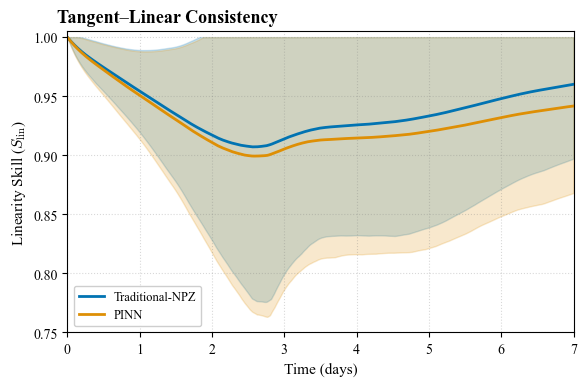


=== Linearity Skill Summary ===
Traditional-NPZ final skill: 0.9601 ± 0.0630
PINN final skill: 0.9417 ± 0.0736

Traditional-NPZ minimum skill: 0.9071 at day 2.56
PINN minimum skill: 0.8993 at day 2.62


In [9]:
# ---------------------------------------------------------------------
# Ensemble means and standard deviations (across sampled pairs)
# ---------------------------------------------------------------------
# shape: (n_pairs, n_time)
s_lin_ref_mean = s_lin_ref_t.mean(axis=0)
s_lin_ref_std  = s_lin_ref_t.std(axis=0)

s_lin_pinn_mean = s_lin_pinn_t.mean(axis=0)
s_lin_pinn_std  = s_lin_pinn_t.std(axis=0)

# Optional: if you also have PI-NPZ
if "s_lin_pi_npz_t" in locals():
    s_lin_pi_npz_mean = s_lin_pi_npz_t.mean(axis=0)
    s_lin_pi_npz_std  = s_lin_pi_npz_t.std(axis=0)
    
# ---------------------------------------------------------------------
# Matplotlib typography: AGU/JAMES style
# ---------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ---------------------------------------------------------------------
# Color scheme: Paul Tol's colorblind-friendly palette
# ---------------------------------------------------------------------
trad_npz_color = "#0173B2"  # blue
pinn_color     = "#DE8F05"  # orange

# ---------------------------------------------------------------------
# Time axis
# ---------------------------------------------------------------------
time = truth_t

# ---------------------------------------------------------------------
# Figure: Linearity Skill Score
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

# --- Traditional-NPZ ---
ax.plot(time, s_lin_ref_mean, color=trad_npz_color, lw=2, label="Traditional-NPZ")
ax.fill_between(
    time,
    s_lin_ref_mean - s_lin_ref_std,
    np.minimum(s_lin_ref_mean + s_lin_ref_std, 1.0),
    color=trad_npz_color,
    alpha=0.2,
)

# --- PI-NPZ (if available) ---
if "s_lin_pi_npz_mean" in locals():
    ax.plot(time, s_lin_pi_npz_mean, color=pi_npz_color, lw=2, label="PI-NPZ")
    ax.fill_between(
        time,
        s_lin_pi_npz_mean - s_lin_pi_npz_std,
        np.minimum(s_lin_pi_npz_mean + s_lin_pi_npz_std, 1.0),
        color=pi_npz_color,
        alpha=0.2,
    )

# --- PINN ---
ax.plot(time, s_lin_pinn_mean, color=pinn_color, lw=2, label="PINN")
ax.fill_between(
    time,
    s_lin_pinn_mean - s_lin_pinn_std,
    np.minimum(s_lin_pinn_mean + s_lin_pinn_std, 1.0),
    color=pinn_color,
    alpha=0.2,
)

# ---------------------------------------------------------------------
# Axis labels and limits
# ---------------------------------------------------------------------
ax.set_xlabel("Time (days)")
ax.set_ylabel(r"Linearity Skill ($S_{\mathrm{lin}}$)")
ax.set_xlim(time[0], time[-1])
ax.set_ylim(0.75, 1.005)

# ---------------------------------------------------------------------
# Grid and legend
# ---------------------------------------------------------------------
ax.grid(True, linestyle=":", alpha=0.3, color="gray")
ax.legend(loc="lower left", framealpha=0.95)

# ---------------------------------------------------------------------
# Title and layout
# ---------------------------------------------------------------------
ax.text(
    -0.02,
    1.03,
    "Tangent–Linear Consistency",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    ha="left",
)
plt.tight_layout()

# ---------------------------------------------------------------------
# Export (vector for paper, high-DPI PNG optional)
# ---------------------------------------------------------------------
# file_base = f"../figures/linearity_skill_{sample_size}_samples"
# for ext, dpi in [("pdf", None)]:
#     plt.savefig(f"{file_base}.{ext}", bbox_inches="tight", pad_inches=0.02, dpi=dpi)

plt.show()

# ---------------------------------------------------------------------
# Print summary statistics
# ---------------------------------------------------------------------
print("\n=== Linearity Skill Summary ===")
print(f"Traditional-NPZ final skill: {s_lin_ref_mean[-1]:.4f} ± {s_lin_ref_std[-1]:.4f}")
if "s_lin_pi_npz_mean" in locals():
    print(f"PI-NPZ final skill: {s_lin_pi_npz_mean[-1]:.4f} ± {s_lin_pi_npz_std[-1]:.4f}")
print(f"PINN final skill: {s_lin_pinn_mean[-1]:.4f} ± {s_lin_pinn_std[-1]:.4f}")

print(f"\nTraditional-NPZ minimum skill: {s_lin_ref_mean.min():.4f} at day {time[s_lin_ref_mean.argmin()]:.2f}")
if "s_lin_pi_npz_mean" in locals():
    print(f"PI-NPZ minimum skill: {s_lin_pi_npz_mean.min():.4f} at day {time[s_lin_pi_npz_mean.argmin()]:.2f}")
print(f"PINN minimum skill: {s_lin_pinn_mean.min():.4f} at day {time[s_lin_pinn_mean.argmin()]:.2f}")


## Single-step Dynamics Based on Background States

To assess whether the network's learned sensitivities are ecologically meaningful, we compare Jacobians against both the embedded PI-NPZ equations and Traditional-NPZ.
Our controlled experiment provides a unique validation opportunity: the embedded equations supply known, differentiable Jacobians that we can compare directly against those learned by the network.
This comparison reveals whether the structural assumptions were preserved or modified to align with the data.
Alignment across both references indicates that the embedded equations accurately capture the true dynamics, while divergence highlights how the network compensates for misspecified functional forms.

### PI-NPZ Embedded Equations Jacobian Function

In [10]:
def npz_jacobian(state, alpha, beta, b, c, e, f):
    """
    Compute analytical Jacobian for simplified NPZ model
    
    Args:
        state: [N, P, Z] array
        alpha, beta, m, q, e, g: model parameters
    """
    N, P, Z = state
    
    # Compute common terms
    tanh_term = np.tanh(beta * N)
    
    # sech²(βN) = 1/cosh²(βN) = 1 - tanh²(βN)
    # This is the derivative of tanh(βN) with respect to its argument
    sech2_term = 1 - tanh_term**2
    
    # The derivative of tanh(βN) with respect to N is:
    # d/dN[tanh(βN)] = β * sech²(βN) = β * (1 - tanh²(βN))
    dtanh_dN = beta * sech2_term
    
    # Build Jacobian matrix
    J = np.array([
        # First row: ∂(dN/dt)/∂[N,P,Z]
        [-alpha * beta * P * sech2_term,
         -alpha * tanh_term + b + f * Z,
         c + f * P],
        
        # Second row: ∂(dP/dt)/∂[N,P,Z]
        [alpha * beta * P * sech2_term,
         alpha * tanh_term - b - (e + f) * Z,
         -(e + f) * P],
        
        # Third row: ∂(dZ/dt)/∂[N,P,Z]
        [0,
         e * Z,
         e * P - c]
    ])
    
    return J

In [11]:
jacobian_test_states = pd.read_csv("../data/training_validation_data/npz_jacobian_test_set.csv", index_col=False)
print(jacobian_test_states.head())


          N         P         Z
0  1.205411  0.233808  0.631770
1  1.481965  0.176771  0.151407
2  0.412914  1.270935  0.136839
3  0.159189  1.385666  0.323213
4  1.375635  0.412555  0.135306


In [12]:
# Load in states
states_all = jacobian_test_states[['N', 'P', 'Z']].values  # just the state columns
# --- Helpers ---
def pinn_disc_jacobian_dimensional_at_state(model, x_dim, nd_ntot, dtype=torch.float64, device='cpu'):
    """
    Compute discrete Jacobian (3x3) of the PINN one-step map at a given dimensional state.
    """
    x_nd = torch.as_tensor(x_dim / np.asarray(nd_ntot), dtype=dtype, device=device).unsqueeze(0)
    J_list = compute_jacobians(
        model=model,
        nd_trajectory=x_nd, 
        nd_ntot=nd_ntot,
        return_dimensional=True,
        dtype=dtype,
        device=device
    )
    return J_list[0][:3, :3].detach().cpu().numpy()  # (3,3)


def pinn_npz_tl(tl_x, x, t, alpha, beta, b, c, e, f):
    """
    Tangent-linear model for the PI-NPZ system.
    
    Args:
        tl_x : array_like
            Perturbation state [δN, δP, δZ]
        x : array_like
            Base state [N, P, Z]
        t : float
            Time (unused, but included for API consistency)
        alpha, beta, b, c, e, f : floats
            PI-NPZ model parameters
    Returns:
        tl_dx : ndarray
            Time derivative of perturbations [d(δN)/dt, d(δP)/dt, d(δZ)/dt]
    """
    N, P, Z = np.asarray(x)
    dN, dP, dZ = np.asarray(tl_x)

    # Precompute nonlinear terms
    tanh_term = np.tanh(beta * N)
    sech2_term = 1.0 - tanh_term**2

    tl_dx = np.zeros_like(x)

    # delta_N tendency
    tl_dx[0] = (
        (-alpha * beta * P * sech2_term) * dN
        + (-alpha * tanh_term + b + f * Z) * dP
        + (c + f * P) * dZ
    )

    # delta_P tendency
    tl_dx[1] = (
        (alpha * beta * P * sech2_term) * dN
        + (alpha * tanh_term - b - (e + f) * Z) * dP
        + (-(e + f) * P) * dZ
    )

    # delta_Z tendency
    tl_dx[2] = (
        (0.0) * dN
        + (e * Z) * dP
        + (e * P - c) * dZ
    )

    return tl_dx


def npz_disc_jacobian_rk4_at_state(x_dim, dt, params):
    """
    Compute discrete Jacobian (3x3) of the embedded PI-NPZ equations
    using RK4 + tangent-linear model.
    """
    nvar = len(x_dim)
    J = np.zeros((nvar, nvar))
    for j in range(nvar):
        delta0 = np.zeros(nvar)
        delta0[j] = 1.0
        tl_traj = rk4_tl(
            f=embedded_npz,          # PI-NPZ dynamics
            tl_f=pinn_npz_tl,    # tangent-linear PI-NPZ
            x=np.vstack([x_dim, np.zeros_like(x_dim)]),
            tl_x0=delta0,
            times=np.array([0.0, dt]),
            tfrc=None,
            frc=None,
            args=params
        )
        J[:, j] = tl_traj[-1]
    return J

def franks_npz_disc_jacobian_rk4_at_state(x_dim, dt, params):
    """
    Compute discrete Jacobian (3x3) of the embedded PI-NPZ equations
    using RK4 + tangent-linear model.
    """
    nvar = len(x_dim)
    J = np.zeros((nvar, nvar))
    for j in range(nvar):
        delta0 = np.zeros(nvar)
        delta0[j] = 1.0
        tl_traj = rk4_tl(
            f=npz_nl,          # PI-NPZ dynamics
            tl_f=npz_tl,    # tangent-linear PI-NPZ
            x=np.vstack([x_dim, np.zeros_like(x_dim)]),
            tl_x0=delta0,
            times=np.array([0.0, dt]),
            tfrc=None,
            frc=None,
            args=params
        )
        J[:, j] = tl_traj[-1]
    return J

# --- Metrics ---
expected_signs = {(0,1):-1, (1,0):+1, (1,2):-1, (2,1):+1}
def sign_consistency(J, tol=1e-6):
    ok = []
    for (i,j), s in expected_signs.items():
        v = J[i, j]
        actual = 0 if abs(v) < tol else (1 if v > 0 else -1)
        ok.append((s == 0) or (s == actual))
    return np.mean(ok)

def row_cosines(Jp, Jt, eps=1e-12):
    return np.array([(Jp[i,:] @ Jt[i,:]) / (norm(Jp[i,:])*norm(Jt[i,:]) + eps) for i in range(3)])

def discrete_stability(J):
    return np.max(np.abs(eigvals(J))) < 1.0

# --- Loop over states ---
alpha = 1.2164
beta = 1.2795
b = 0.1
c = 0.2
e = 0.5
f = 0.5
pi_npz_params = (alpha, beta, b, c, e, f)
# --- Loop over states ---
J_pinn_list, J_pi_npz_list, J_franks_list = [], [], []
metrics_pi_npz, metrics_franks = [], []

for x_b in states_all:
    # Jacobians
    Jp       = pinn_disc_jacobian_dimensional_at_state(pi_npz_model, x_b, nd_ntot)
    J_pi_npz = npz_disc_jacobian_rk4_at_state(x_b, dt, pi_npz_params)
    J_franks = franks_npz_disc_jacobian_rk4_at_state(x_b, dt, phi)

    # Store
    J_pinn_list.append(Jp)
    J_pi_npz_list.append(J_pi_npz)
    J_franks_list.append(J_franks)

    # --- Metrics: PINN vs PI-NPZ ---
    frob_pi   = norm(Jp - J_pi_npz, 'fro') / max(norm(J_pi_npz, 'fro'), 1e-12)
    sign_pi   = sign_consistency(Jp)
    rcos_pi   = row_cosines(Jp, J_pi_npz)
    stab_pi   = (discrete_stability(Jp) == discrete_stability(J_pi_npz))
    metrics_pi_npz.append((frob_pi, sign_pi, rcos_pi, stab_pi))

    # --- Metrics: PINN vs Franks ---
    frob_fr   = norm(Jp - J_franks, 'fro') / max(norm(J_franks, 'fro'), 1e-12)
    sign_fr   = sign_consistency(Jp)
    rcos_fr   = row_cosines(Jp, J_franks)
    stab_fr   = (discrete_stability(Jp) == discrete_stability(J_franks))
    metrics_franks.append((frob_fr, sign_fr, rcos_fr, stab_fr))

# --- Convert lists → arrays ---
J_pinn_all   = np.stack(J_pinn_list)
J_pi_npz_all = np.stack(J_pi_npz_list)
J_franks_all = np.stack(J_franks_list)

metrics_pi_npz = np.array(metrics_pi_npz, dtype=object)
metrics_franks = np.array(metrics_franks, dtype=object)

# --- Unpack metrics ---
frob_pi_arr, sign_pi_arr, rowcos_pi_arr, stab_pi_arr = zip(*metrics_pi_npz)
frob_fr_arr, sign_fr_arr, rowcos_fr_arr, stab_fr_arr = zip(*metrics_franks)

# Convert to arrays for stats
frob_pi_arr   = np.array(frob_pi_arr)
sign_pi_arr   = np.array(sign_pi_arr)
rowcos_pi_arr = np.vstack(rowcos_pi_arr)
stab_pi_arr   = np.array(stab_pi_arr)

frob_fr_arr   = np.array(frob_fr_arr)
sign_fr_arr   = np.array(sign_fr_arr)
rowcos_fr_arr = np.vstack(rowcos_fr_arr)
stab_fr_arr   = np.array(stab_fr_arr)

# --- Summary printout ---
def summarize(label, frob, sign, rowcos, stab):
    print(f"\n=== {len(frob)}-State Jacobian Comparison (PINN vs {label}) ===")
    print(f"Mean relative Frobenius error: {frob.mean()*100:.3f}% "
          f"(median {np.median(frob)*100:.3f}%)")
    print(f"Sign consistency: {sign.mean()*100:.1f}%")
    print(f"Row-wise cosine similarity (mean per row): {rowcos.mean(axis=0)}")
    print(f"Stability match rate: {stab.mean()*100:.1f}%")

summarize("PI-NPZ", frob_pi_arr, sign_pi_arr, rowcos_pi_arr, stab_pi_arr)
summarize("Franks NPZ", frob_fr_arr, sign_fr_arr, rowcos_fr_arr, stab_fr_arr)



=== 2000-State Jacobian Comparison (PINN vs PI-NPZ) ===
Mean relative Frobenius error: 0.203% (median 0.193%)
Sign consistency: 96.0%
Row-wise cosine similarity (mean per row): [0.99999884 0.99999864 0.9999989 ]
Stability match rate: 81.8%

=== 2000-State Jacobian Comparison (PINN vs Franks NPZ) ===
Mean relative Frobenius error: 0.032% (median 0.025%)
Sign consistency: 96.0%
Row-wise cosine similarity (mean per row): [0.99999995 0.99999995 0.99999997]
Stability match rate: 84.4%


In [13]:
def make_specs(J_ref_all, J_pinn_all, nvar, nticks=5, pad=0.05):
    """
    Auto-generate axis specs for Jacobian comparison grids.
    
    nticks: number of ticks per axis (default 5)
    pad: fractional padding relative to data range (default 5%)
    """
    specs = {}
    for i in range(nvar):
        for j in range(nvar):
            x = J_ref_all[:, i, j].flatten()
            y = J_pinn_all[:, i, j].flatten()
            vmin = min(x.min(), y.min())
            vmax = max(x.max(), y.max())

            # Handle edge case: very narrow range (avoid identical min/max)
            if np.isclose(vmin, vmax):
                vmin -= 0.001
                vmax += 0.001

            # Add fractional padding
            rng = vmax - vmin
            vmin -= pad * rng
            vmax += pad * rng

            # Evenly spaced ticks
            xticks = np.linspace(vmin, vmax, nticks)
            yticks = np.linspace(vmin, vmax, nticks)

            specs[(i, j)] = {
                "xlim": (vmin, vmax),
                "ylim": (vmin, vmax),
                "xticks": np.round(xticks, 3),
                "yticks": np.round(yticks, 3),
            }
    return specs


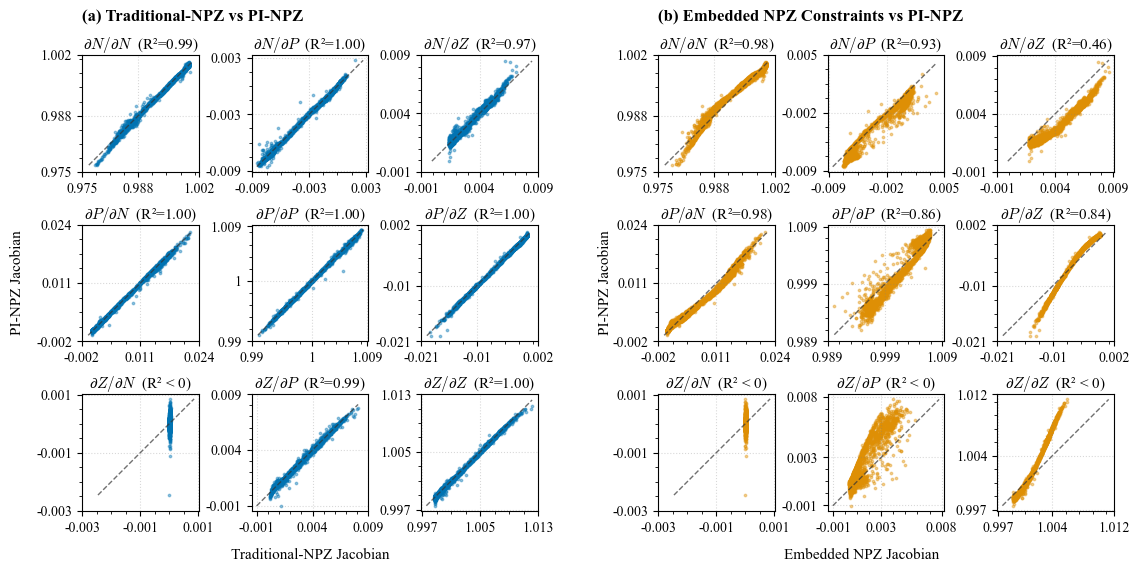


=== Jacobian Comparison Summary ===

PI-NPZ Equations vs PINN R² values:
Component pair | R²
-------------------------
∂N/∂N     | 0.976
∂N/∂P     | 0.929
∂N/∂Z     | 0.461
∂P/∂N     | 0.980
∂P/∂P     | 0.858
∂P/∂Z     | 0.839
∂Z/∂N     | -1593.095
∂Z/∂P     | -0.647
∂Z/∂Z     | -0.297
Mean R²: -176.555

Traditional NPZ Equations vs PINN R² values:
Component pair | R²
-------------------------
∂N/∂N     | 0.995
∂N/∂P     | 0.995
∂N/∂Z     | 0.974
∂P/∂N     | 0.998
∂P/∂P     | 0.998
∂P/∂Z     | 0.999
∂Z/∂N     | -368.939
∂Z/∂P     | 0.992
∂Z/∂Z     | 0.997
Mean R²: -40.110


In [14]:
# ======================================================
# Jacobian Comparison Figure (PI-NPZ / Traditional vs PINN)
# ======================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from matplotlib.ticker import FixedLocator
import matplotlib.gridspec as gridspec

# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Colors
scatter_color_pi = "#DE8F05"      # Orange
scatter_color_franks = "#0173B2"  # Blue
line_color = "#333333"
r2_color = "#000000"

labels = ["N", "P", "Z"]
nvar = 3

custom_specs_pi = make_specs(J_pi_npz_all, J_pinn_all, nvar, nticks=3)
custom_specs_franks = make_specs(J_franks_all, J_pinn_all, nvar, nticks=3)

# ======================================================
# Create figure with 2 panels (side by side grids)
# ======================================================
fig = plt.figure(figsize=(12, 6))

gs_left = gridspec.GridSpec(
    nvar, nvar,
    left=0.08, right=0.46, top=0.88, bottom=0.12,
    hspace=0.45, wspace=0.45   # <- increase spacing inside the grid
)
gs_right = gridspec.GridSpec(
    nvar, nvar,
    left=0.56, right=0.94, top=0.88, bottom=0.12,
    hspace=0.45, wspace=0.45   # <- same here
)


r2_values_pi = np.zeros((nvar, nvar))
r2_values_franks = np.zeros((nvar, nvar))

# ======================================================
# Panel (b) Traditional NPZ Equations vs PINN
# ======================================================
for i in range(nvar):
    for j in range(nvar):
        ax = fig.add_subplot(gs_left[i, j])

        x = J_franks_all[:, i, j].flatten()
        y = J_pinn_all[:, i, j].flatten()

        # Scatter
        ax.scatter(x, y, s=3, alpha=0.4, color=scatter_color_franks, rasterized=True)

        # 1:1 line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                "--", color=line_color, lw=1, alpha=0.7)

        ax.set_aspect("equal", adjustable="box")

        # Grid
        ax.grid(True, linestyle=":", alpha=0.3, color="gray")
        ax.minorticks_on()
        # R² annotation
        r2 = r2_score(x, y)
        r2_values_franks[i, j] = r2   # <--- store value
        if r2 < 0:
            r2_str = "R² < 0"
        else:
            r2_str = f"R²={r2:.2f}"
        ax.set_title(f"$\\partial {labels[i]} / \\partial {labels[j]}$  ({r2_str})",
                     fontsize=11, pad=2)

        # Apply custom specs if available
        spec = custom_specs_franks.get((i, j))
        # Example: replace inside your loop where you apply specs
        if spec:
            ax.set_xlim(spec["xlim"])
            ax.set_ylim(spec["ylim"])
            ax.set_xticks(spec["xticks"])
            ax.set_yticks(spec["yticks"])
            # Explicitly set tick labels at the same positions
            ax.set_xticklabels([f"{t:g}" for t in spec["xticks"]])
            ax.set_yticklabels([f"{t:g}" for t in spec["yticks"]])

# Panel title
fig.text(0.08, 0.93, "(a) Traditional-NPZ vs PI-NPZ",
         fontsize=12, fontweight="bold", ha="left", va="bottom")
# Shared labels
fig.text(0.27, 0.04, "Traditional-NPZ Jacobian", fontsize=11, ha="center")
fig.text(0.02, 0.50, "PI-NPZ Jacobian", fontsize=11, va="center", rotation="vertical")

# ======================================================
# Panel (a) PI-NPZ Equations vs PINN
# ======================================================
for i in range(nvar):
    for j in range(nvar):
        ax = fig.add_subplot(gs_right[i, j])

        x = J_pi_npz_all[:, i, j].flatten()
        y = J_pinn_all[:, i, j].flatten()

        # Scatter
        ax.scatter(x, y, s=3, alpha=0.4, color=scatter_color_pi, rasterized=True)

        # 1:1 line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                "--", color=line_color, lw=1, alpha=0.7)

        ax.set_aspect("equal", adjustable="box")

        # Grid
        ax.grid(True, linestyle=":", alpha=0.3, color="gray")
        ax.minorticks_on()

        r2 = r2_score(x, y)
        r2_values_pi[i, j] = r2   # <--- store value
        if r2 < 0:
            r2_str = "R² < 0"
        else:
            r2_str = f"R²={r2:.2f}"
        ax.set_title(f"$\\partial {labels[i]} / \\partial {labels[j]}$  ({r2_str})",
                     fontsize=11, pad=2)

        # Apply custom specs if available
        spec = custom_specs_pi.get((i, j))
        # Example: replace inside your loop where you apply specs
        if spec:
            ax.set_xlim(spec["xlim"])
            ax.set_ylim(spec["ylim"])
            ax.set_xticks(spec["xticks"])
            ax.set_yticks(spec["yticks"])
            # Explicitly set tick labels at the same positions
            ax.set_xticklabels([f"{t:g}" for t in spec["xticks"]])
            ax.set_yticklabels([f"{t:g}" for t in spec["yticks"]])

# Panel title
fig.text(0.56, 0.93, "(b) Embedded NPZ Constraints vs PI-NPZ",
         fontsize=12, fontweight="bold", ha="left", va="bottom")
# Shared labels
fig.text(0.73, 0.04, "Embedded NPZ Jacobian", fontsize=11, ha="center")
fig.text(0.51, 0.50, "PI-NPZ Jacobian", fontsize=11, va="center", rotation="vertical")

# plt.tight_layout(rect=[0, 0, 1, 0.9])

# Save in multiple formats
# base_path = "../figures/"
# file_base = "jacobian_scatter_custom"
# for ext in ["pdf"]:
#     dpi = 600 if ext == "png" else None
#     plt.savefig(f"{base_path}{file_base}.{ext}",
#                 dpi=dpi, bbox_inches="tight", pad_inches=0.02,
#                 format=ext)

plt.show()

# ======================================================
# Print summary statistics
# ======================================================
print("\n=== Jacobian Comparison Summary ===")

print("\nPI-NPZ Equations vs PINN R² values:")
print("Component pair | R²")
print("-" * 25)
for i in range(nvar):
    for j in range(nvar):
        print(f"∂{labels[i]}/∂{labels[j]:5} | {r2_values_pi[i,j]:.3f}")
print(f"Mean R²: {r2_values_pi.mean():.3f}")

print("\nTraditional NPZ Equations vs PINN R² values:")
print("Component pair | R²")
print("-" * 25)
for i in range(nvar):
    for j in range(nvar):
        print(f"∂{labels[i]}/∂{labels[j]:5} | {r2_values_franks[i,j]:.3f}")
print(f"Mean R²: {r2_values_franks.mean():.3f}")
